<h1>SwiftPrime — AI-Based Premium Customer Identification System</h1>


**Objective**: Build a machine learning pipeline to identify customers most likely to belong to the premium segment (Income > 50K), rank them by probability, and recommend the Top 20% for the SwiftPrime membership program.


In [1]:
import warnings
warnings.filterwarnings('ignore')


import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib import rcParams
import seaborn as sns
%matplotlib inline

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

# Imbalanced handling
from imblearn.over_sampling import SMOTE


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix,
    precision_recall_curve, roc_curve, average_precision_score
)


from sklearn.model_selection import RandomizedSearchCV


import shap


import os
import joblib


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('All libraries loaded successfully!')

All libraries loaded successfully!


# Loading Dataset

In [2]:
train_df = pd.read_csv('Census_income_train.csv')
test_df  = pd.read_csv('Census_income_test.csv')

# About the Dataset

- **Age:** Describes the age of individuals. *(Continuous numerical attribute.)*

- **Workclass:** Employment type. Categories include:
  - Private
  - Self-emp-not-inc
  - Self-emp-inc
  - Federal-gov
  - Local-gov
  - State-gov
  - Without-pay
  - Never-worked

- **fnlwgt:** Final sampling weight assigned by the Census Bureau. *(Continuous numerical attribute.)*

- **Education:** Highest education level attained. Categories include:
  - Bachelors
  - Some-college
  - 11th
  - HS-grad
  - Prof-school
  - Assoc-acdm
  - Assoc-voc
  - 9th
  - 7th-8th
  - 12th
  - Masters
  - 1st-4th
  - 10th
  - Doctorate
  - 5th-6th
  - Preschool

- **Education-num:** Number of years of education completed. *(Continuous numerical attribute.)*

- **Marital-status:** Marital status of the individual. Categories include:
  - Married-civ-spouse
  - Divorced
  - Never-married
  - Separated
  - Widowed
  - Married-spouse-absent
  - Married-AF-spouse

- **Occupation:** Type of occupation. Categories include:
  - Tech-support
  - Craft-repair
  - Other-service
  - Sales
  - Exec-managerial
  - Prof-specialty
  - Handlers-cleaners
  - Machine-op-inspct
  - Adm-clerical
  - Farming-fishing
  - Transport-moving
  - Priv-house-serv
  - Protective-serv
  - Armed-Forces

- **Relationship:** Family relationship status. Categories include:
  - Wife
  - Own-child
  - Husband
  - Not-in-family
  - Other-relative
  - Unmarried

- **Race:** Ethnic group of the individual. Categories include:
  - White
  - Asian-Pac-Islander
  - Amer-Indian-Eskimo
  - Other
  - Black

- **Sex:** Gender of the individual.
  - Female
  - Male

- **Capital-gain:** Capital gains earned during the year. *(Continuous numerical attribute.)*

- **Capital-loss:** Capital losses incurred during the year. *(Continuous numerical attribute.)*

- **Hours-per-week:** Average number of working hours per week. *(Continuous numerical attribute.)*

- **Native-country:** Country of origin. Categories include:
  - United-States
  - Cambodia
  - England
  - Puerto-Rico
  - Canada
  - Germany
  - Outlying-US (Guam-USVI-etc)
  - India
  - Japan
  - Greece
  - South
  - China
  - Cuba
  - Iran
  - Honduras
  - Philippines
  - Italy
  - Poland
  - Jamaica
  - Vietnam
  - Mexico
  - Portugal
  - Ireland
  - France
  - Dominican-Republic
  - Laos
  - Ecuador
  - Taiwan
  - Haiti
  - Columbia
  - Hungary
  - Guatemala
  - Nicaragua
  - Scotland
  - Thailand
  - Yugoslavia
  - El-Salvador
  - Trinadad&Tobago
  - Peru
  - Hong
  - Holand-Netherlands

- **Salary (Target Variable):**
  - **>50K:** Annual income greater than \$50,000.
  - **<=50K:** Annual income less than or equal to \$50,000.

# Data Quality Assessment

In [3]:
print("="*30)
print("DATASET SHAPE")
print("="*30)

print(train_df.shape)
print(test_df.shape)

DATASET SHAPE
(32560, 15)
(16281, 15)


In [4]:
print("="*30)
print("DATA TYPES")
print("="*30)

dtype_df = pd.DataFrame({
    "Column": train_df.columns,
    "Data Type": train_df.dtypes.values
})

display(dtype_df)

DATA TYPES


,Column,Data Type
0,Age,int64
1,Workclass,str
2,fnlwgt,int64
3,Education,str
4,Education-num,int64
5,Marital status,str
6,Occupation,str
7,Relationship,str
8,Race,str
9,Sex,str


In [5]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32560 entries, 0 to 32559
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Age             32560 non-null  int64
 1   Workclass       32560 non-null  str  
 2   fnlwgt          32560 non-null  int64
 3   Education       32560 non-null  str  
 4   Education-num   32560 non-null  int64
 5   Marital status  32560 non-null  str  
 6   Occupation      32560 non-null  str  
 7   Relationship    32560 non-null  str  
 8   Race            32560 non-null  str  
 9   Sex             32560 non-null  str  
 10  Capital-gain    32560 non-null  int64
 11  Capital-loss    32560 non-null  int64
 12  Hours-per-week  32560 non-null  int64
 13  Native-country  32560 non-null  str  
 14  Income          32560 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.5 MB


In [6]:
print("="*50)
print("DUPLICATE RECORDS")
print("="*50)

train_duplicates = train_df.duplicated().sum()
test_duplicates = test_df.duplicated().sum()

print(f"Train Duplicates : {train_duplicates}")
print(f"Test Duplicates  : {test_duplicates}")

DUPLICATE RECORDS
Train Duplicates : 24
Test Duplicates  : 5


In [7]:
train_df = train_df.drop_duplicates().reset_index(drop=True)
test_df = test_df.drop_duplicates().reset_index(drop=True)

In [8]:
print("="*50)
print("DUPLICATE RECORDS")
print("="*50)

train_duplicates = train_df.duplicated().sum()
test_duplicates = test_df.duplicated().sum()

print(f"Train Duplicates : {train_duplicates}")
print(f"Test Duplicates  : {test_duplicates}")

DUPLICATE RECORDS
Train Duplicates : 0
Test Duplicates  : 0


In [9]:
print("="*50)
print("MISSING VALUES")
print("="*50)

display(pd.DataFrame({
    "Missing Count": train_df.isnull().sum(),
    "Missing %": round(train_df.isnull().mean()*100,2)
}))



MISSING VALUES


,Missing Count,Missing %
Age,0,0.0
Workclass,0,0.0
fnlwgt,0,0.0
Education,0,0.0
Education-num,0,0.0
Marital status,0,0.0
Occupation,0,0.0
Relationship,0,0.0
Race,0,0.0
Sex,0,0.0


In [10]:
print("="*50)
print("UNIQUE CATEGORIES")
print("="*50)

cat_cols = train_df.select_dtypes(include='object').columns

unique_df = pd.DataFrame({
    "Column": cat_cols,
    "Unique Values": [train_df[col].nunique() for col in cat_cols]
})

display(unique_df)

UNIQUE CATEGORIES


,Column,Unique Values
0,Workclass,9
1,Education,16
2,Marital status,7
3,Occupation,15
4,Relationship,6
5,Race,5
6,Sex,2
7,Native-country,41
8,Income,2


In [11]:
for col in cat_cols:
    print(f"\n{col}")
    print(train_df[col].unique())


Workclass
<ArrowStringArray>
[       ' State-gov', ' Self-emp-not-inc',          ' Private',
      ' Federal-gov',        ' Local-gov',                ' ?',
     ' Self-emp-inc',      ' Without-pay',     ' Never-worked']
Length: 9, dtype: str

Education
<ArrowStringArray>
[   ' Bachelors',      ' HS-grad',         ' 11th',      ' Masters',
          ' 9th', ' Some-college',   ' Assoc-acdm',    ' Assoc-voc',
      ' 7th-8th',    ' Doctorate',  ' Prof-school',      ' 5th-6th',
         ' 10th',      ' 1st-4th',    ' Preschool',         ' 12th']
Length: 16, dtype: str

Marital status
<ArrowStringArray>
[        ' Never-married',    ' Married-civ-spouse',              ' Divorced',
 ' Married-spouse-absent',             ' Separated',     ' Married-AF-spouse',
               ' Widowed']
Length: 7, dtype: str

Occupation
<ArrowStringArray>
[     ' Adm-clerical',   ' Exec-managerial', ' Handlers-cleaners',
    ' Prof-specialty',     ' Other-service',             ' Sales',
      ' Craft-repair

**Observation**

- We have observed question mark in the dataset

In [12]:
cat_cols = train_df.select_dtypes(include='object').columns

for col in cat_cols:
    train_unique = set(train_df[col].unique())
    test_unique = set(test_df[col].unique())

    if train_unique == test_unique:
        print(f" {col}: Same")
    else:
        print(f"\n {col}: Different")
        print("Only in Train:", train_unique - test_unique)
        print("Only in Test :", test_unique - train_unique)

 Workclass: Same
 Education: Same
 Marital status: Same
 Occupation: Same
 Relationship: Same
 Race: Same
 Sex: Same
 Native-country: Same

 Income: Different
Only in Train: {' >50K', ' <=50K'}
Only in Test : {' >50K.', ' <=50K.'}


In [13]:
for df in [train_df, test_df]:
    df['Income'] = df['Income'].str.replace('.', '', regex=False)

In [14]:
numeric_cols = train_df.select_dtypes(include=['int64','float64']).columns

train_df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,32536.0,38.585751,13.638144,17.0,28.0,37.0,48.00,90.0
fnlwgt,32536.0,189785.824502,105554.276950,12285.0,117831.5,178356.0,236993.25,1484705.0
Education-num,32536.0,10.081817,2.571672,1.0,9.0,10.0,12.00,16.0
Capital-gain,32536.0,1078.476887,7388.068543,0.0,0.0,0.0,0.00,99999.0
Capital-loss,32536.0,87.303141,402.937025,0.0,0.0,0.0,0.00,4356.0
Hours-per-week,32536.0,40.440343,12.347079,1.0,40.0,40.0,45.00,99.0


**Observation**

- The minimum and maximum age of people in the dataset is 19 and 90 years respectively, while the average age is 37.
- The minimum and maximum years spent on education is 1 and 16 respectively, whereas the mean education level is 10 years.

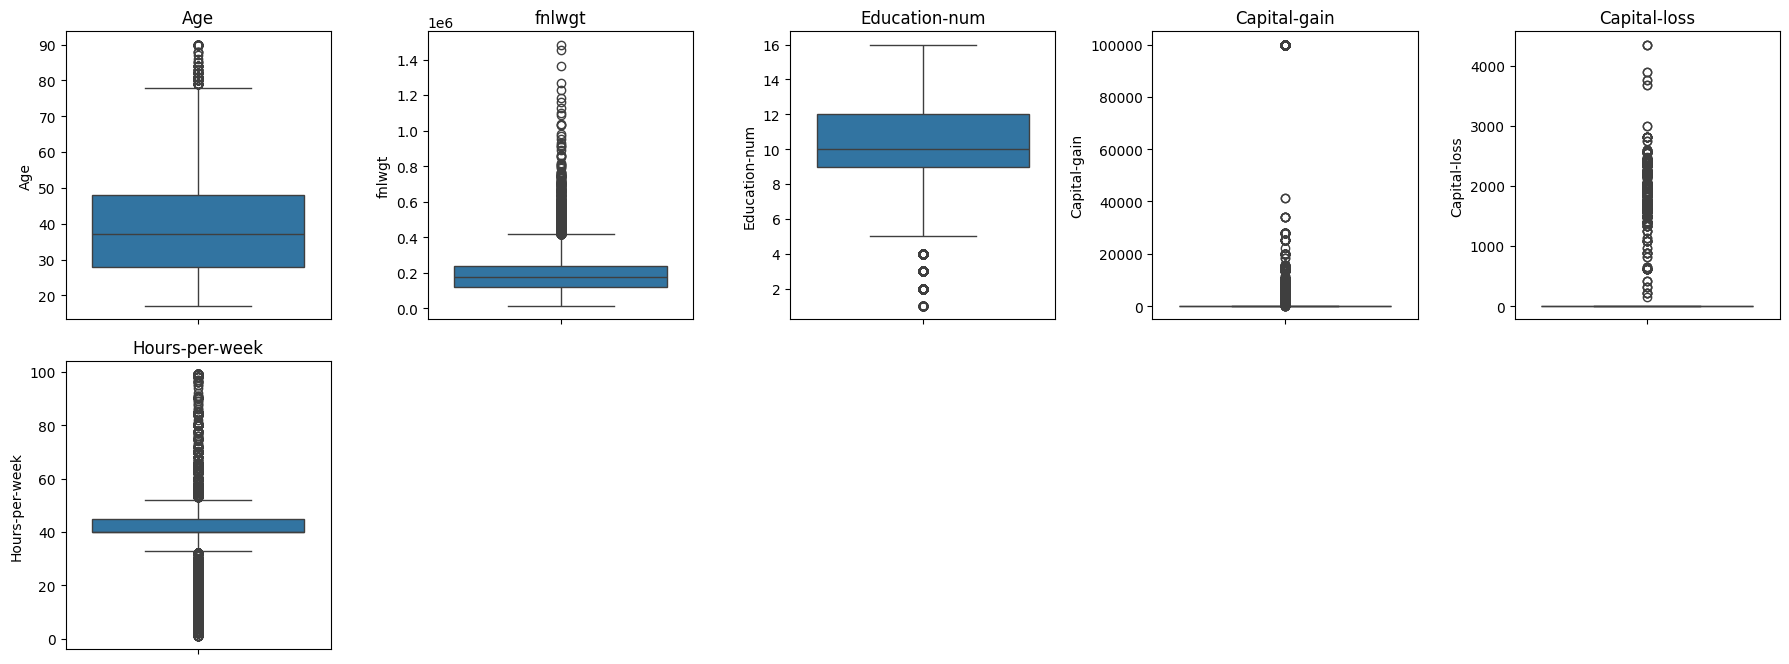

In [15]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18,10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 5, i)
    sns.boxplot(data=train_df, y=col)
    plt.title(col)

plt.tight_layout()
plt.show()

In [16]:
print("="*50)
print("OUTLIER COUNT (IQR METHOD)")
print("="*50)

outlier_summary = []

for col in numeric_cols:

    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = ((train_df[col] < lower) | (train_df[col] > upper)).sum()

    outlier_summary.append([col, outliers])

outlier_df = pd.DataFrame(outlier_summary,
                          columns=["Feature","Outlier Count"])

display(outlier_df)

OUTLIER COUNT (IQR METHOD)


,Feature,Outlier Count
0,Age,142
1,fnlwgt,993
2,Education-num,1193
3,Capital-gain,2712
4,Capital-loss,1518
5,Hours-per-week,9002


In [17]:
summary = pd.DataFrame({
    "Data Type": train_df.dtypes,
    "Missing": train_df.isnull().sum(),
    "Unique": train_df.nunique()
})

display(summary)

,Data Type,Missing,Unique
Age,int64,0,73
Workclass,str,0,9
fnlwgt,int64,0,21647
Education,str,0,16
Education-num,int64,0,16
Marital status,str,0,7
Occupation,str,0,15
Relationship,str,0,6
Race,str,0,5
Sex,str,0,2


In [18]:
for df in [train_df, test_df]:
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].str.strip()

- We observed that some features in the dataset contain question marks (?), which represent missing values. These missing values were replaced with the most frequently occurring value (mode) of the corresponding feature.

In [19]:
for df in [train_df, test_df]:
    df.replace('?', np.nan, inplace=True)

In [20]:
total = train_df.isnull().sum().sort_values(ascending=False)
percent = train_df.isnull().sum() / len(train_df) * 100

pd.concat([total, percent], axis=1, keys=['Total', '%'])

,Total,%
Occupation,1843,5.664495
Workclass,1836,5.642980
Native-country,582,1.788788
Age,0,0.000000
fnlwgt,0,0.000000
Education,0,0.000000
Education-num,0,0.000000
Marital status,0,0.000000
Relationship,0,0.000000
Race,0,0.000000


In [21]:
for col in ['Workclass', 'Occupation', 'Native-country']:
    mode = train_df[col].mode()[0]

    train_df[col].fillna(mode, inplace=True)
    test_df[col].fillna(mode, inplace=True)

In [22]:
for df in [train_df, test_df]:
    df['Income'] = df['Income'].map({'<=50K':0,'>50K':1})

In [23]:
train_df.head()

,Age,Workclass,fnlwgt,Education,Education-num,Marital status,Occupation,Relationship,Race,Sex,Capital-gain,Capital-loss,Hours-per-week,Native-country,Income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0


In [24]:
train_df.tail()

,Age,Workclass,fnlwgt,Education,Education-num,Marital status,Occupation,Relationship,Race,Sex,Capital-gain,Capital-loss,Hours-per-week,Native-country,Income
32531,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,0
32532,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,1
32533,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,0
32534,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,0
32535,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,1


# Exploratory Data Analysis (EDA)

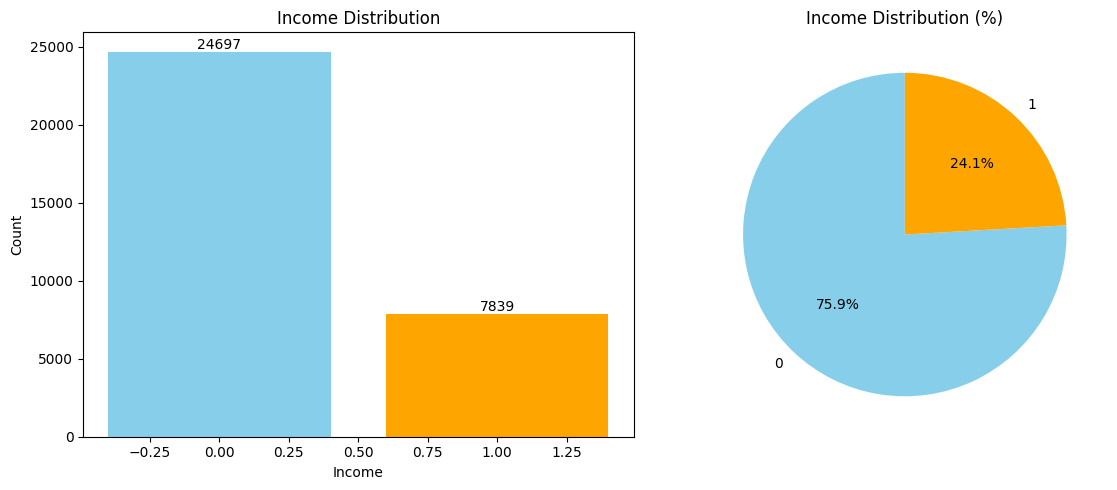

In [25]:
import matplotlib.pyplot as plt


target_counts = train_df['Income'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(12, 5))


bars = ax[0].bar(target_counts.index, target_counts.values,
                 color=['skyblue', 'orange'])

ax[0].set_title("Income Distribution")
ax[0].set_xlabel("Income")
ax[0].set_ylabel("Count")

# Show count on bars
for bar in bars:
    height = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2,
               height,
               f'{int(height)}',
               ha='center',
               va='bottom',
               fontsize=10)


ax[1].pie(target_counts.values,
          labels=target_counts.index,
          autopct='%1.1f%%',
          colors=['skyblue', 'orange'],
          startangle=90)

ax[1].set_title("Income Distribution (%)")

plt.tight_layout()
plt.show()

**Observation**

- The income distribution is imbalanced, with 75.9% of individuals earning ≤50K and only 24.1% earning >50K.

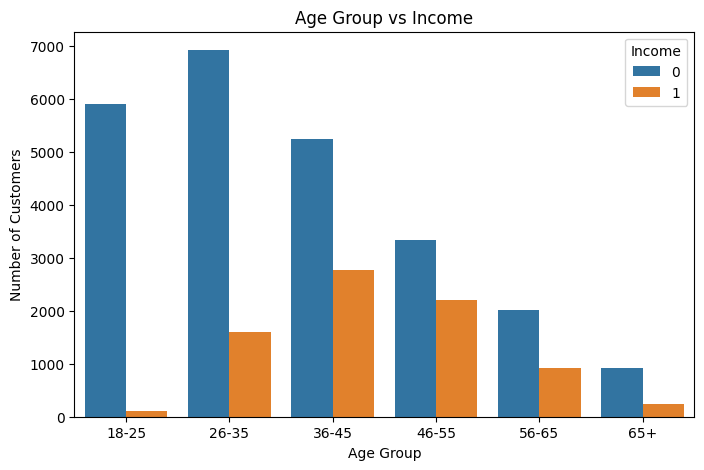

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt


train_df['Age Group'] = pd.cut(
    train_df['Age'],
    bins=[17, 25, 35, 45, 55, 65, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
)

plt.figure(figsize=(8,5))

sns.countplot(
    data=train_df,
    x='Age Group',
    hue='Income'
)

plt.title('Age Group vs Income')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.legend(title='Income')
plt.show()

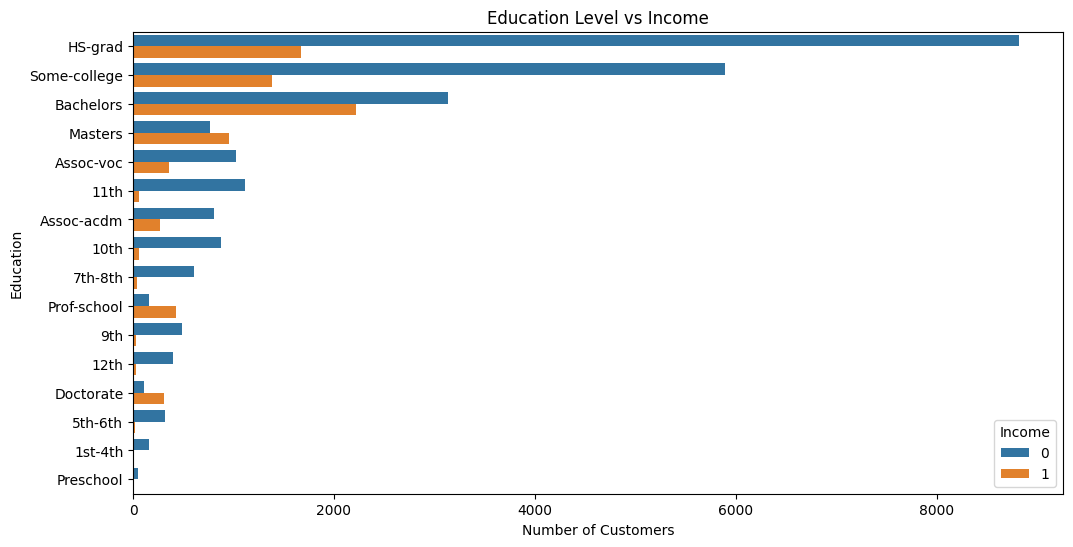

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.countplot(
    data=train_df,
    y='Education',
    hue='Income',
    order=train_df['Education'].value_counts().index
)

plt.title("Education Level vs Income")
plt.xlabel("Number of Customers")
plt.ylabel("Education")
plt.show()

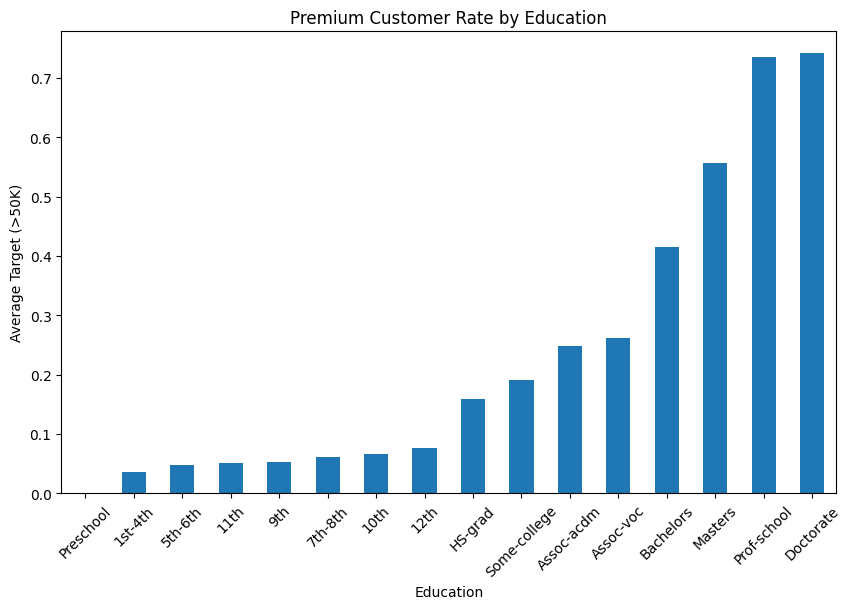

In [28]:
edu = train_df.groupby('Education')['Income'].mean().sort_values()

plt.figure(figsize=(10,6))

edu.plot(kind='bar')

plt.title("Premium Customer Rate by Education")
plt.xlabel("Education")
plt.ylabel("Average Target (>50K)")
plt.xticks(rotation=45)

plt.show()

KEY INSIGHT: Clear staircase pattern — higher education = higher premium rate (Doctorate: ~74%).

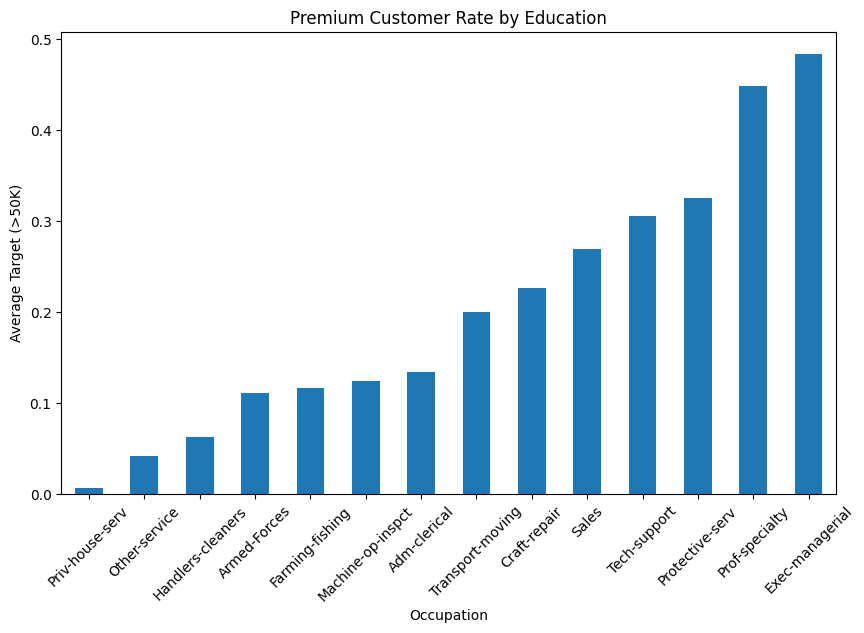

In [29]:
edu = train_df.groupby('Occupation')['Income'].mean().sort_values()

plt.figure(figsize=(10,6))

edu.plot(kind='bar')

plt.title("Premium Customer Rate by Education")
plt.xlabel("Occupation")
plt.ylabel("Average Target (>50K)")
plt.xticks(rotation=45)

plt.show()

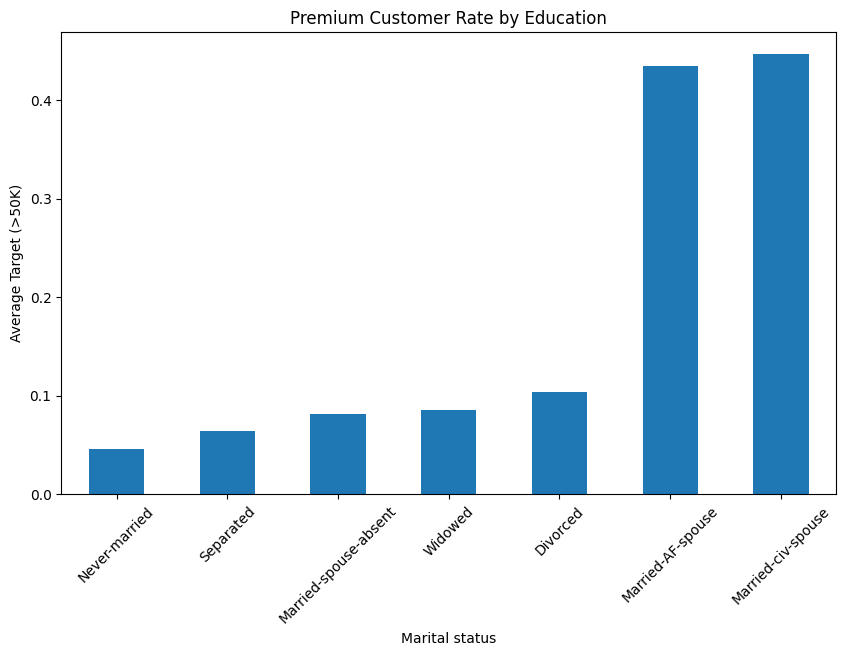

In [30]:
edu = train_df.groupby('Marital status')['Income'].mean().sort_values()

plt.figure(figsize=(10,6))

edu.plot(kind='bar')

plt.title("Premium Customer Rate by Education")
plt.xlabel("Marital status")
plt.ylabel("Average Target (>50K)")
plt.xticks(rotation=45)

plt.show()

KEY INSIGHT: Married-civ-spouse has strong premium rate — strongest marital predictor.

<Axes: xlabel='Income', ylabel='count'>

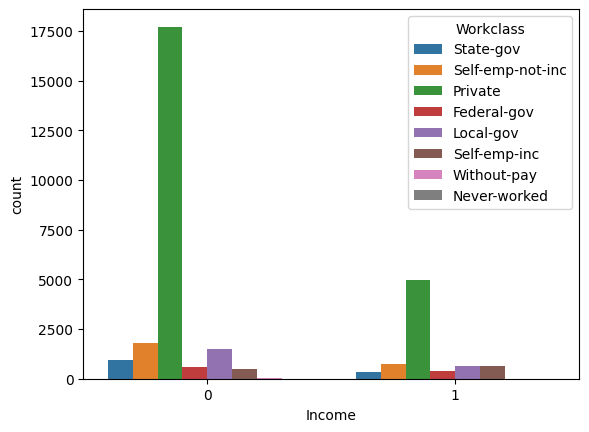

In [31]:
sns.countplot(x = 'Income', hue = 'Workclass', data = train_df)

# Feature Engineering

In [32]:
for df in [train_df, test_df]:
    df['Age Group'] = pd.cut(
        df['Age'],
        bins=[0, 25, 40, 60, 100],
        labels=['Young', 'Mid-age', 'Senior', 'Elder']
    )

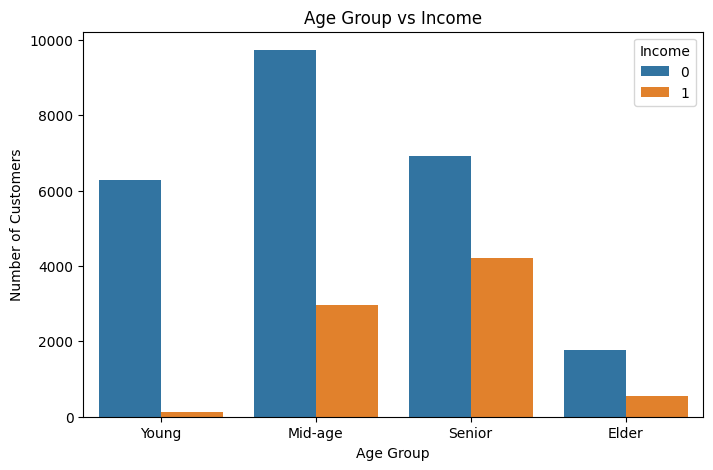

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    data=train_df,
    x='Age Group',
    hue='Income'
)

plt.title("Age Group vs Income")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.show()

In [34]:
corr = train_df.select_dtypes(include='number').corr()

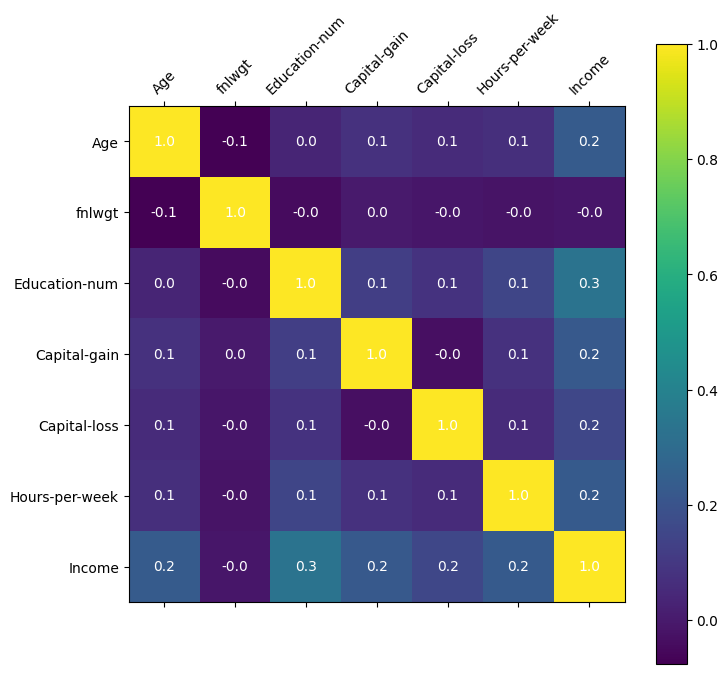

In [35]:

plt.rcParams['figure.figsize'] = (10, 8)   # Figure size

plt.matshow(corr, fignum=1, cmap='viridis')
plt.colorbar()

plt.xticks(np.arange(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(np.arange(len(corr.columns)), corr.columns)

for (i, j), value in np.ndenumerate(corr):
    plt.text(j, i, f"{value:.1f}",
             ha='center',
             va='center',
             color='white',
             fontsize=10)

plt.show()

**Observation**
- The fnlwgt feature has a correlation value close to zero with the target variable. Therefore, it was dropped from the dataset as it contributes little to the prediction

In [36]:
for df in [train_df, test_df]:
    df.drop('fnlwgt', axis=1, inplace=True)

In [37]:
def engineer_features(df):
    df = df.copy()

    
    df['capital_net'] = df['Capital-gain'] - df['Capital-loss']
    df['has_capital_activity'] = ((df['Capital-gain'] > 0) | (df['Capital-loss'] > 0)).astype(int)
    df['log_capital_gain'] = np.log1p(df['Capital-gain'])
    df['log_capital_loss'] = np.log1p(df['Capital-loss'])

    
    df['is_married'] = (df['Marital status'] == 'Married-civ-spouse').astype(int)

    
    edu_map = {
        'Preschool': 'Dropout', '1st-4th': 'Dropout', '5th-6th': 'Dropout',
        '7th-8th': 'Dropout', '9th': 'Dropout', '10th': 'Dropout',
        '11th': 'Dropout', '12th': 'Dropout',
        'HS-grad': 'HS-grad',
        'Some-college': 'Some-college', 'Assoc-voc': 'Some-college', 'Assoc-acdm': 'Some-college',
        'Bachelors': 'Graduate',
        'Masters': 'Post-grad', 'Prof-school': 'Post-grad', 'Doctorate': 'Post-grad'
    }
    df['education_group'] = df['Education'].map(edu_map).fillna('Other')

  
    high_skill = ['Exec-managerial', 'Prof-specialty', 'Tech-support', 'Protective-serv']
    df['high_skill_occ'] = df['Occupation'].isin(high_skill).astype(int)

    
    df['is_self_employed'] = df['Workclass'].isin(['Self-emp-inc', 'Self-emp-not-inc']).astype(int)


    return df

train_df = engineer_features(train_df)
test_df  = engineer_features(test_df)

print('Feature engineering complete!')
print(f'Train shape after FE: {train_df.shape}')
print('\nNew features added:')
new_feats = ['capital_net','has_capital_activity','log_capital_gain','log_capital_loss',
             'is_married','education_group','high_skill_occ','is_self_employed']
for f in new_feats:
    print(f'  ✦ {f}')


Feature engineering complete!
Train shape after FE: (32536, 23)

New features added:
  ✦ capital_net
  ✦ has_capital_activity
  ✦ log_capital_gain
  ✦ log_capital_loss
  ✦ is_married
  ✦ education_group
  ✦ high_skill_occ
  ✦ is_self_employed


# Model Preparation — Encoding & Scaling

In [38]:
from sklearn.preprocessing import LabelEncoder

cat_cols = train_df.select_dtypes(include=['object', 'category']).columns

le_dict = {}

for col in cat_cols:
    if col != 'Income':
        le = LabelEncoder()

        combined = pd.concat([
            train_df[col].astype(str),
            test_df[col].astype(str)
        ])

        le.fit(combined)

        le_dict[col] = le

        train_df[col] = le.transform(train_df[col].astype(str))
        test_df[col] = le.transform(test_df[col].astype(str))

In [39]:
X_train = train_df.drop('Income', axis=1)
Y_train = train_df['Income']

X_test = test_df.drop('Income', axis=1)
Y_test = test_df['Income']


In [40]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    'XGBoost': XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        verbosity=0
    )
}

results = []

print("Training Models...\n")

for name, model in models.items():

    model.fit(X_train, Y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(Y_test, y_pred)
    auc = roc_auc_score(Y_test, y_prob)
    f1 = f1_score(Y_test, y_pred)
    pr_auc = average_precision_score(Y_test, y_prob)

    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'ROC-AUC': round(auc, 4),
        'F1-Score': round(f1, 4),
        'PR-AUC': round(pr_auc, 4)
    })

    print(f'{name:22s} | Accuracy: {acc:.4f} | ROC-AUC: {auc:.4f} | F1: {f1:.4f} | PR-AUC: {pr_auc:.4f}')

results_df = (
    pd.DataFrame(results)
    .sort_values('ROC-AUC', ascending=False)
    .reset_index(drop=True)
)

display(results_df)

Training Models...

Logistic Regression    | Accuracy: 0.8380 | ROC-AUC: 0.8829 | F1: 0.6082 | PR-AUC: 0.7242
Random Forest          | Accuracy: 0.8534 | ROC-AUC: 0.9005 | F1: 0.6685 | PR-AUC: 0.7739
XGBoost                | Accuracy: 0.8729 | ROC-AUC: 0.9276 | F1: 0.7091 | PR-AUC: 0.8264


,Model,Accuracy,ROC-AUC,F1-Score,PR-AUC
0,XGBoost,0.8729,0.9276,0.7091,0.8264
1,Random Forest,0.8534,0.9005,0.6685,0.7739
2,Logistic Regression,0.8380,0.8829,0.6082,0.7242



 MODEL COMPARISON TABLE (Sorted by ROC-AUC)

              Model  Accuracy  ROC-AUC  F1-Score  PR-AUC
            XGBoost    0.8729   0.9276    0.7091  0.8264
      Random Forest    0.8534   0.9005    0.6685  0.7739
Logistic Regression    0.8380   0.8829    0.6082  0.7242


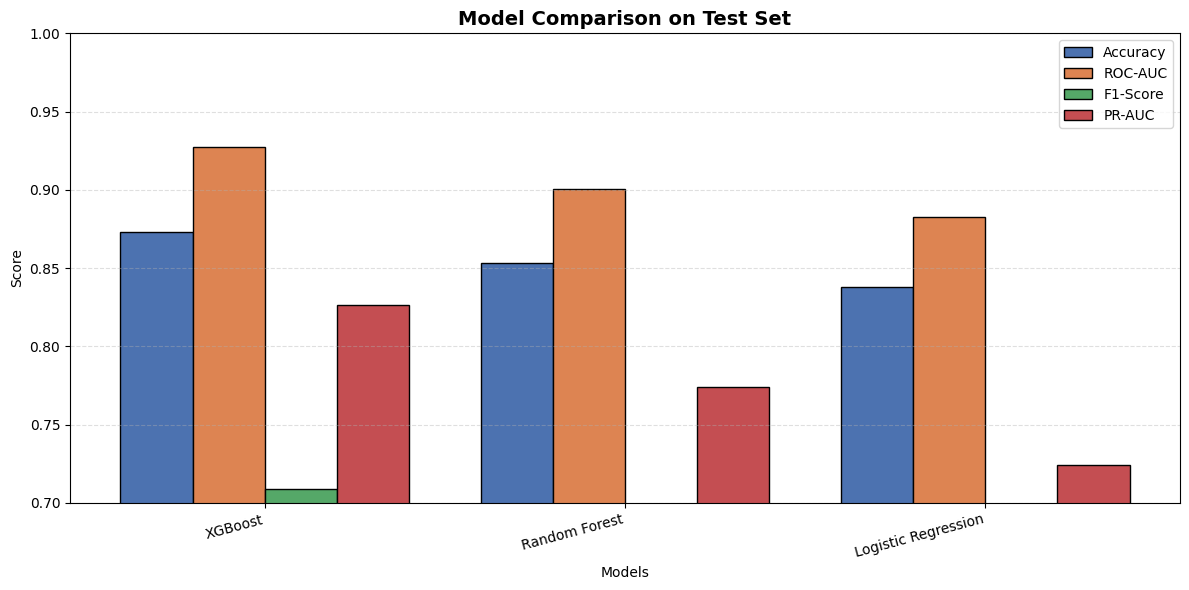

In [41]:
# ── Model Comparison Table ───────────────────────────────────────────────
print("\n MODEL COMPARISON TABLE (Sorted by ROC-AUC)\n")
print(results_df.to_string(index=False))

# ── Visual Comparison ────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(results_df))
width = 0.2

metrics = ['Accuracy', 'ROC-AUC', 'F1-Score', 'PR-AUC']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for i, metric in enumerate(metrics):
    ax.bar(
        x + i * width,
        results_df[metric],
        width,
        label=metric,
        color=colors[i],
        edgecolor='black'
    )

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')

ax.set_ylabel('Score')
ax.set_xlabel('Models')
ax.set_ylim(0.70, 1.00)
ax.set_title('Model Comparison on Test Set', fontsize=14, fontweight='bold')

ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.savefig("model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

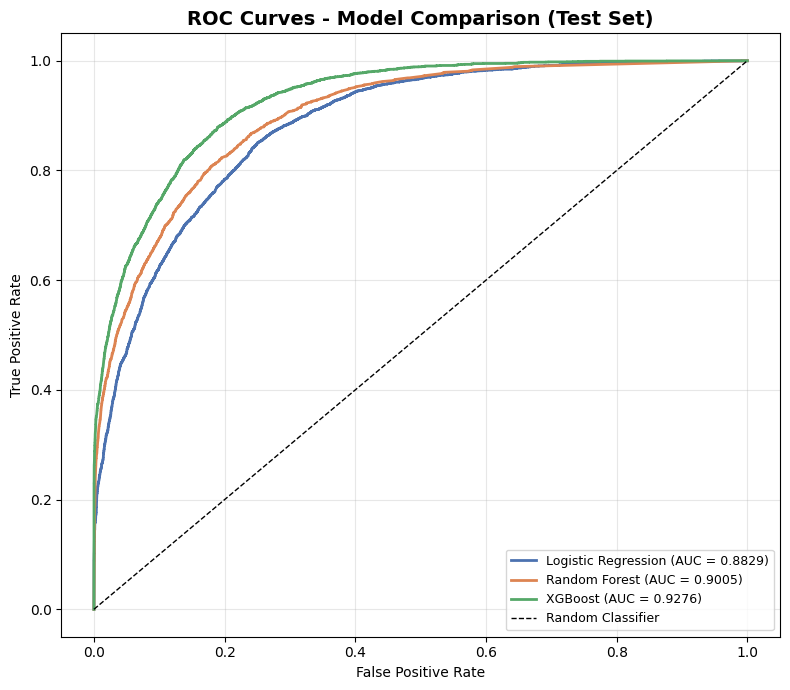

In [42]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt


fig, ax = plt.subplots(figsize=(8, 7))

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

for (name, model), color in zip(models.items(), colors):

    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(Y_test, y_prob)
    auc = roc_auc_score(Y_test, y_prob)

    ax.plot(
        fpr,
        tpr,
        color=color,
        linewidth=2,
        label=f'{name} (AUC = {auc:.4f})'
    )

# Random classifier
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - Model Comparison (Test Set)', fontsize=14, fontweight='bold')

ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

### Manual Hyperparameter Tuning for Random Forest Model

In [43]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

model = random_forest

model.fit(X_train, Y_train)
pred = model.predict(X_test)

print(f' Accuracy: {accuracy_score(Y_test, pred)}')

 Accuracy: 0.8683337429343819


### Manual Hyperparameter Tuning for XGBoost

In [44]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, Y_train)

pred = xgb.predict(X_test)

print(f' Accuracy: {accuracy_score(Y_test, pred)}')

 Accuracy: 0.8734947161464733


In [45]:
from sklearn.metrics import classification_report

pred = xgb.predict(X_test)

print("Classification Report\n")
print(classification_report(Y_test, pred))

Classification Report

              precision    recall  f1-score   support

           0       0.90      0.94      0.92     12430
           1       0.77      0.66      0.71      3846

    accuracy                           0.87     16276
   macro avg       0.84      0.80      0.81     16276
weighted avg       0.87      0.87      0.87     16276



## Hyperparameter Tuning — Best Model (XGBoost)

In [46]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

params = {
    'n_estimators': [200, 300, 400, 500, 700],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2]
}

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=params,
    n_iter=20,
    scoring='accuracy',
    cv=5,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, Y_train)

print(search.best_params_)
print(search.best_score_)

{'subsample': 0.9, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.8}
0.8734633469756791


TUNED XGBOOST — TEST SET RESULTS
Accuracy : 0.8744
ROC-AUC  : 0.9281
F1-Score : 0.7114
PR-AUC   : 0.8278

Classification Report
              precision    recall  f1-score   support

       <=50K       0.90      0.94      0.92     12430
        >50K       0.78      0.65      0.71      3846

    accuracy                           0.87     16276
   macro avg       0.84      0.80      0.82     16276
weighted avg       0.87      0.87      0.87     16276



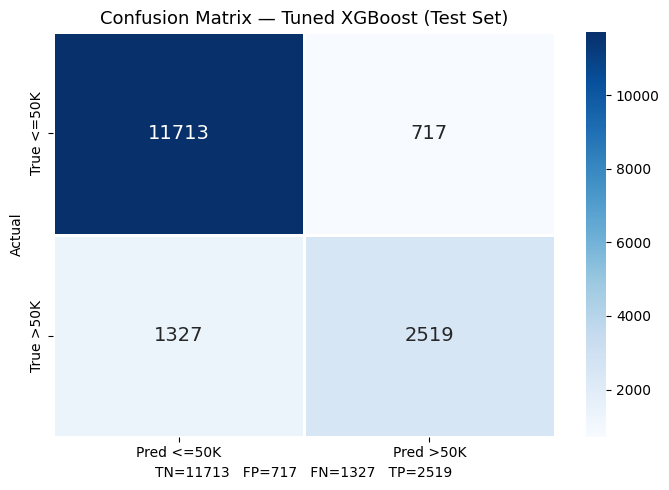


Business Cost Interpretation
----------------------------------------
False Negatives (missed premium customers): 1,327  
False Positives (wrongly invited):          717  


In [47]:

best_model = search.best_estimator_

y_test_pred_best  = best_model.predict(X_test)
y_test_proba_best = best_model.predict_proba(X_test)[:, 1]

print("=" * 60)
print("TUNED XGBOOST — TEST SET RESULTS")
print("=" * 60)

print(f"Accuracy : {accuracy_score(Y_test, y_test_pred_best):.4f}")
print(f"ROC-AUC  : {roc_auc_score(Y_test, y_test_proba_best):.4f}")
print(f"F1-Score : {f1_score(Y_test, y_test_pred_best):.4f}")
print(f"PR-AUC   : {average_precision_score(Y_test, y_test_proba_best):.4f}")

print("\nClassification Report")
print(classification_report(
    Y_test,
    y_test_pred_best,
    target_names=['<=50K', '>50K']
))


cm = confusion_matrix(Y_test, y_test_pred_best)

fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=1,
    linecolor='white',
    annot_kws={'size':14},
    xticklabels=['Pred <=50K', 'Pred >50K'],
    yticklabels=['True <=50K', 'True >50K'],
    ax=ax
)

ax.set_title('Confusion Matrix — Tuned XGBoost (Test Set)', fontsize=13)

tn, fp, fn, tp = cm.ravel()

ax.set_xlabel(f'TN={tn}   FP={fp}   FN={fn}   TP={tp}', fontsize=10)
ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nBusiness Cost Interpretation")
print("-" * 40)
print(f"False Negatives (missed premium customers): {fn:,}  ")
print(f"False Positives (wrongly invited):          {fp:,}  ")

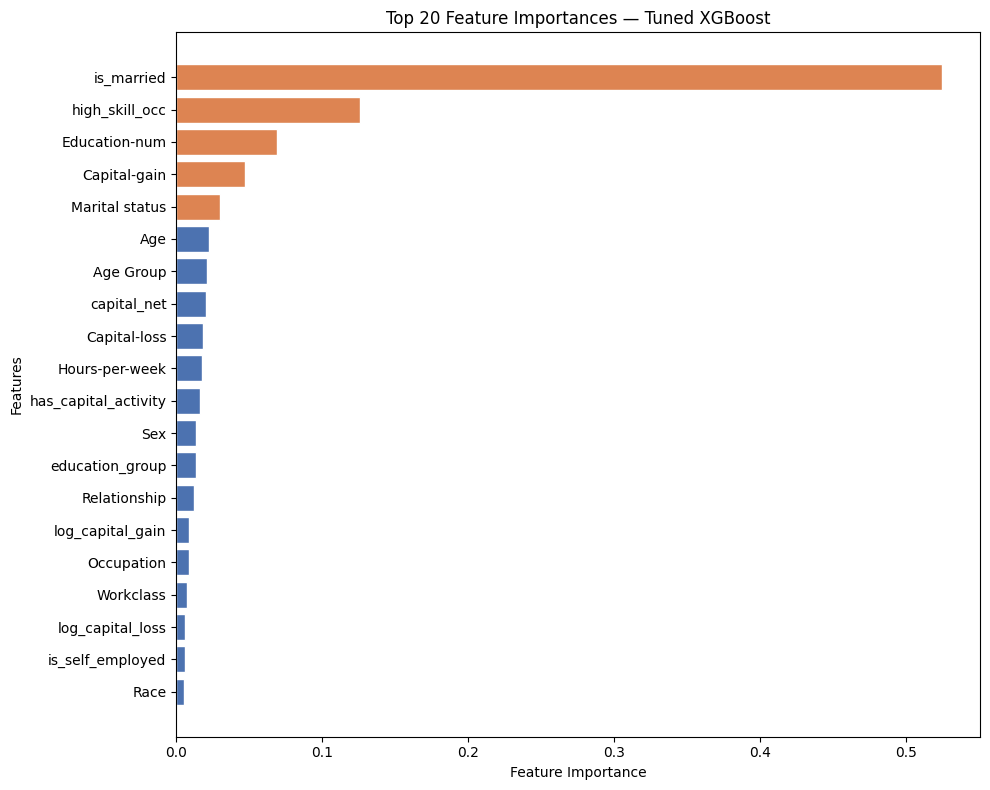

In [48]:

feat_imp = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 8))

colors = [
    '#DD8452' if v > feat_imp.quantile(0.75) else '#4C72B0'
    for v in feat_imp.values
]

ax.barh(
    feat_imp.index,
    feat_imp.values,
    color=colors,
    edgecolor='white'
)

ax.set_xlabel('Feature Importance')
ax.set_ylabel('Features')
ax.set_title('Top 20 Feature Importances — Tuned XGBoost')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

In [49]:

y_test_pred  = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)[:, 1]

print("=" * 60)
print("TUNED XGBOOST — TEST SET RESULTS")
print("=" * 60)

print(f"Accuracy : {accuracy_score(Y_test, y_test_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(Y_test, y_test_proba):.4f}")
print(f"F1-Score : {f1_score(Y_test, y_test_pred):.4f}")
print(f"PR-AUC   : {average_precision_score(Y_test, y_test_proba):.4f}")

print("\nClassification Report")
print(classification_report(
    Y_test,
    y_test_pred,
    target_names=["<=50K", ">50K"]
))

TUNED XGBOOST — TEST SET RESULTS
Accuracy : 0.8744
ROC-AUC  : 0.9281
F1-Score : 0.7114
PR-AUC   : 0.8278

Classification Report
              precision    recall  f1-score   support

       <=50K       0.90      0.94      0.92     12430
        >50K       0.78      0.65      0.71      3846

    accuracy                           0.87     16276
   macro avg       0.84      0.80      0.82     16276
weighted avg       0.87      0.87      0.87     16276



In [50]:

output_df = test_df.copy()

output_df['premium_probability'] = y_test_proba
output_df['predicted_income'] = np.where(y_test_pred == 1, '>50K', '<=50K')
output_df['actual_income'] = Y_test.values

# Rank by probability (1 = highest probability)
output_df['rank'] = (
    output_df['premium_probability']
    .rank(ascending=False, method='first')
    .astype(int)
)

# Recommend Top 20%
top20_threshold = int(np.ceil(len(output_df) * 0.20))
output_df['recommended_swiftprime'] = (
    output_df['rank'] <= top20_threshold
)

# Priority tiers
def assign_tier(prob):
    if prob >= 0.85:
        return 'Diamond'
    elif prob >= 0.70:
        return 'Platinum'
    elif prob >= 0.50:
        return 'Gold'
    elif prob >= 0.30:
        return 'Silver'
    else:
        return 'Standard'

output_df['priority_tier'] = output_df['premium_probability'].apply(assign_tier)

print(f"Total test customers    : {len(output_df):,}")
print(f"Top 20% cutoff (rank ≤) : {top20_threshold:,}\n")

print("Priority Tier Distribution:")
print(output_df['priority_tier'].value_counts())

# Display selected columns
output_df.head(13)

Total test customers    : 16,276
Top 20% cutoff (rank ≤) : 3,256

Priority Tier Distribution:
priority_tier
Standard    11431
Silver       1609
Gold         1218
Diamond      1212
Platinum      806
Name: count, dtype: int64


,Age,Workclass,Education,Education-num,Marital status,Occupation,Relationship,Race,Sex,Capital-gain,...,is_married,education_group,high_skill_occ,is_self_employed,premium_probability,predicted_income,actual_income,rank,recommended_swiftprime,priority_tier
0,25,3,1,7,4,6,3,2,1,0,...,0,0,0,0,0.001922,<=50K,0,13977,False,Standard
1,38,3,11,9,2,4,0,4,1,0,...,1,2,0,0,0.215583,<=50K,0,5794,False,Standard
2,28,1,7,12,2,10,0,4,1,0,...,1,4,1,0,0.334405,<=50K,1,4509,False,Silver
3,44,3,15,10,2,6,0,2,1,7688,...,1,4,0,0,0.998750,>50K,1,250,True,Diamond
4,18,8,15,10,4,14,3,4,0,0,...,0,4,0,0,0.000162,<=50K,0,15728,False,Standard
5,34,3,0,6,4,7,1,4,1,0,...,0,0,0,0,0.004550,<=50K,0,13091,False,Standard
6,29,8,11,9,4,14,4,2,1,0,...,0,2,0,0,0.005822,<=50K,0,12771,False,Standard
7,63,5,14,15,2,9,0,4,1,3103,...,1,3,1,1,0.938612,>50K,1,975,True,Diamond
8,24,3,15,10,4,7,4,4,0,0,...,0,4,0,0,0.001560,<=50K,0,14153,False,Standard
9,55,3,5,4,2,2,0,4,1,0,...,1,0,0,0,0.028749,<=50K,0,9941,False,Standard


In [51]:

top20 = output_df[output_df['recommended_swiftprime']]
rest = output_df[~output_df['recommended_swiftprime']]

print("=" * 60)
print("TOP 20% SWIFTPRIME RECOMMENDED CUSTOMERS")
print("=" * 60)

print(f"Count                       : {len(top20):,}")
print(f"Average Age                : {top20['Age'].mean():.1f} years")
print(f"Average Age (Others)       : {rest['Age'].mean():.1f} years")
print(f"Actual Premium Rate        : {(top20['actual_income'] == '>50K').mean()*100:.1f}%")
print(f"Average Premium Probability: {top20['premium_probability'].mean():.3f}")

print("\nTop 5 Occupations")
print(top20['Occupation'].value_counts().head(5))

print("\nTop 5 Education Levels")
print(top20['Education'].value_counts().head(5))

TOP 20% SWIFTPRIME RECOMMENDED CUSTOMERS
Count                       : 3,256
Average Age                : 44.9 years
Average Age (Others)       : 37.2 years
Actual Premium Rate        : 0.0%
Average Premium Probability: 0.778

Top 5 Occupations
Occupation
3     993
9     980
11    439
2     201
0     198
Name: count, dtype: int64

Top 5 Education Levels
Education
9     1156
15     546
12     526
11     388
14     212
Name: count, dtype: int64


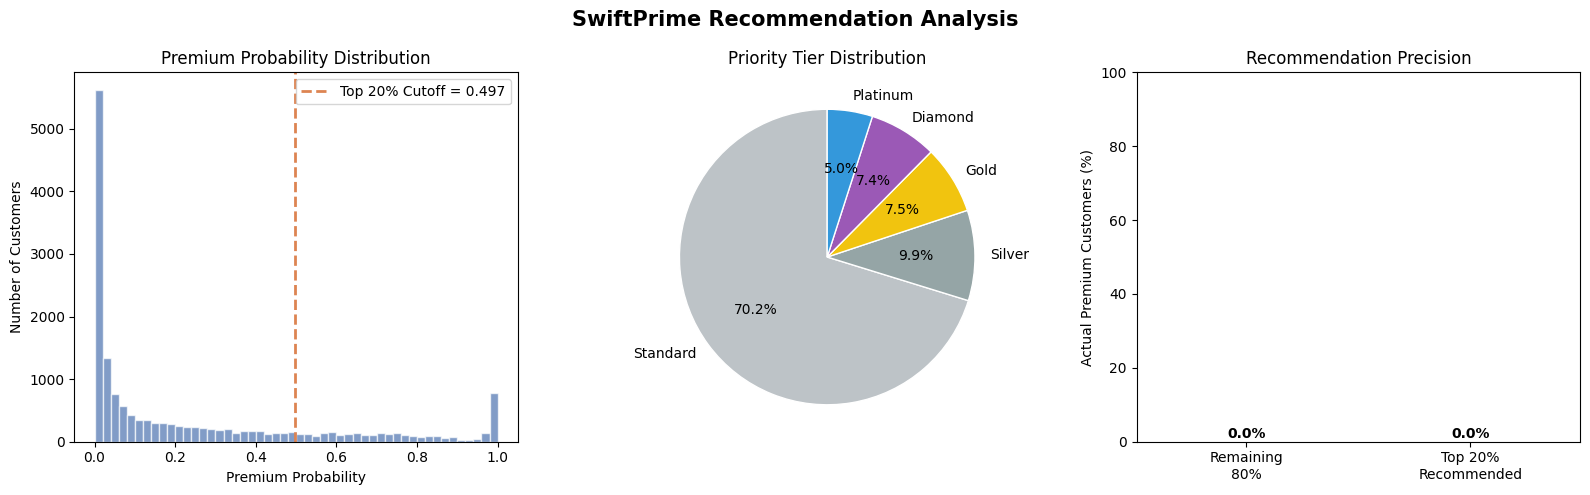

In [52]:

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Premium Probability Distribution
threshold_prob = top20['premium_probability'].min()

axes[0].hist(
    output_df['premium_probability'],
    bins=50,
    color='#4C72B0',
    alpha=0.7,
    edgecolor='white'
)

axes[0].axvline(
    threshold_prob,
    color='#DD8452',
    linestyle='--',
    linewidth=2,
    label=f'Top 20% Cutoff = {threshold_prob:.3f}'
)

axes[0].set_xlabel('Premium Probability')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Premium Probability Distribution')
axes[0].legend()

# 2. Priority Tier Distribution
tier_counts = output_df['priority_tier'].value_counts()

tier_colors = {
    'Diamond':'#9B59B6',
    'Platinum':'#3498DB',
    'Gold':'#F1C40F',
    'Silver':'#95A5A6',
    'Standard':'#BDC3C7'
}

pie_colors = [tier_colors[t] for t in tier_counts.index]

axes[1].pie(
    tier_counts.values,
    labels=tier_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=pie_colors,
    wedgeprops={'edgecolor':'white'}
)

axes[1].set_title('Priority Tier Distribution')

# 3. Recommendation Precision
rec_acc = (
    output_df
    .groupby('recommended_swiftprime')['actual_income']
    .apply(lambda x: (x == '>50K').mean() * 100)
    .reset_index(name='Actual Premium Rate')
)

rec_acc['Group'] = rec_acc['recommended_swiftprime'].map({
    True: 'Top 20%\nRecommended',
    False: 'Remaining\n80%'
})

bars = axes[2].bar(
    rec_acc['Group'],
    rec_acc['Actual Premium Rate'],
    color=['#DD8452', '#4C72B0'],
    edgecolor='white'
)

for bar in bars:
    h = bar.get_height()
    axes[2].text(
        bar.get_x() + bar.get_width()/2,
        h + 1,
        f'{h:.1f}%',
        ha='center',
        fontweight='bold'
    )

axes[2].set_ylim(0, 100)
axes[2].set_ylabel('Actual Premium Customers (%)')
axes[2].set_title('Recommendation Precision')

plt.suptitle('SwiftPrime Recommendation Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('recommendation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [53]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

print("Running 5-Fold Stratified Cross-Validation...")

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    best_model,
    X_train,
    Y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("\nCross-Validation ROC-AUC Scores:")
print(np.round(cv_scores, 4))

print(f"\nMean ROC-AUC : {cv_scores.mean():.4f}")
print(f"Std Dev      : {cv_scores.std():.4f}")

lower = cv_scores.mean() - 2 * cv_scores.std()
upper = cv_scores.mean() + 2 * cv_scores.std()

print(f"95% CI       : [{lower:.4f}, {upper:.4f}]")

if cv_scores.std() < 0.02:
    print("\n Low variance across folds indicates a stable model with good generalization.")
else:
    print("\n Higher variance across folds suggests the model may benefit from further tuning.")

Running 5-Fold Stratified Cross-Validation...

Cross-Validation ROC-AUC Scores:
[0.9248 0.9345 0.9303 0.9271 0.9291]

Mean ROC-AUC : 0.9292
Std Dev      : 0.0033
95% CI       : [0.9227, 0.9357]

 Low variance across folds indicates a stable model with good generalization.


In [54]:
import joblib

export_cols = [
    'Age',
    'Workclass',
    'Education',
    'Marital status',
    'Occupation',
    'Relationship',
    'Race',
    'Sex',
    'Hours-per-week',
    'Native-country',
    'actual_income',
    'predicted_income',
    'premium_probability',
    'rank',
    'recommended_swiftprime',
    'priority_tier'
]

# CSV
output_df[export_cols].to_csv(
    "swiftprime_predictions.csv",
    index=False
)

print(" Exported: swiftprime_predictions.csv")

# Excel
with pd.ExcelWriter("swiftprime_results.xlsx", engine="openpyxl") as writer:

    output_df[export_cols].to_excel(
        writer,
        sheet_name="All_Predictions",
        index=False
    )

    top20[export_cols].sort_values(
        "rank"
    ).to_excel(
        writer,
        sheet_name="Top20_Recommended",
        index=False
    )

    # Include this only if results_df exists
    if 'results_df' in globals():
        results_df.to_excel(
            writer,
            sheet_name="Model_Comparison",
            index=False
        )

print(" Exported: swiftprime_results.xlsx")

joblib.dump(best_model, "xgboost_swiftprime_model.pkl")



if 'le_dict' in globals():
    joblib.dump(le_dict, "label_encoders.pkl")

print(" Model and preprocessing objects saved successfully.")

 Exported: swiftprime_predictions.csv
 Exported: swiftprime_results.xlsx
 Model and preprocessing objects saved successfully.
